#**Assignment 1**


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

In [2]:
fs = 44100
fc = 4000
Ts = 0.0022676
mu = 0.00022676

Ns = int(round(fs * Ts))
Nmu = int(round(mu * fs))

GROUP NUMBER / alpha



In [3]:
group_number = 3

alpha = group_number / 18

## QPSK

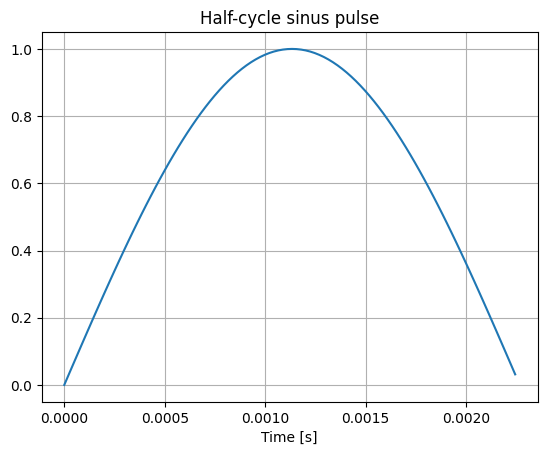

In [4]:
def bits_to_qpsk(bits):
    bits = np.array(bits).astype(int)

    if len(bits) % 2 != 0:
        bits = np.append(bits, 0)

    bit_pairs = bits.reshape(-1, 2)
    symbols = np.zeros(len(bit_pairs), dtype=complex)

    for k, (b1, b2) in enumerate(bit_pairs):
        if (b1, b2) == (0, 0):
            symbols[k] = 1 + 1j
        elif (b1, b2) == (1, 0):
            symbols[k] = -1 + 1j
        elif (b1, b2) == (1, 1):
            symbols[k] = -1 - 1j
        elif (b1, b2) == (0, 1):
            symbols[k] = 1 - 1j

    return symbols

Nbits = 10000
bits = np.random.randint(0, 2, Nbits)
symbols = bits_to_qpsk(bits)

t_pulse = np.arange(Ns) / fs
p = np.sin(np.pi * t_pulse / Ts)

plt.plot(t_pulse, p)
plt.title("Half-cycle sinus pulse")
plt.xlabel("Time [s]")
plt.grid()
plt.show()

## Half-cycle sinus pulse

## Pulse shape

In [5]:
def pulse_shape(symbols, pulse):
  Ns = len(pulse)
  x = np.zeros(len(symbols) * Ns, dtype=complex)

  for k, sym in enumerate(symbols):
    x[k*Ns:(k+1)*Ns] += sym * pulse

  return x

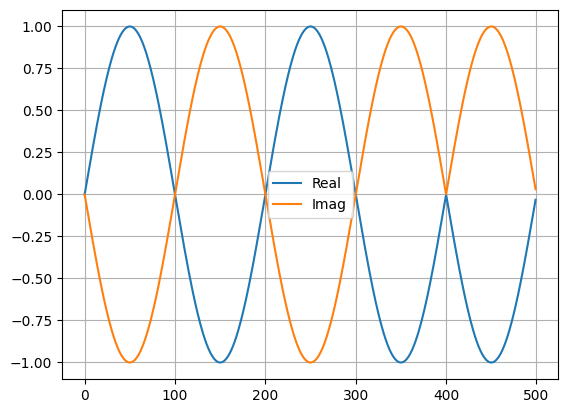

In [6]:
x_bb = pulse_shape(symbols, p)

plt.plot(np.real(x_bb[:5*Ns]), label="Real")
plt.plot(np.imag(x_bb[:5*Ns]), label="Imag")
plt.legend()
plt.grid()
plt.show()

## PAssband modulation

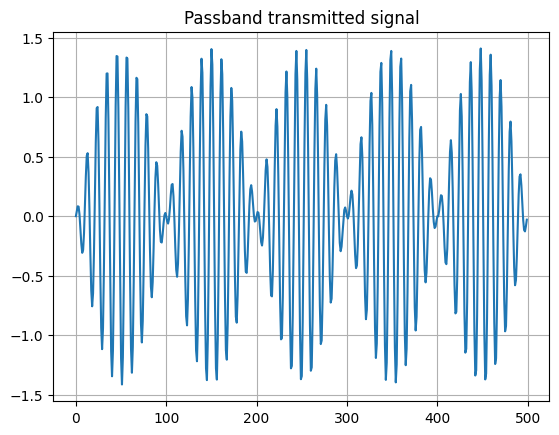

In [7]:
def upconvert(x_bb, fc, fs):
  n = np.arange(len(x_bb))
  carrier = np.exp(1j * 2 * np.pi * fc * n / fs)
  s = np.real(x_bb * carrier)
  return s

s = upconvert(x_bb, fc, fs)

plt.plot(s[:5*Ns])
plt.title("Passband transmitted signal")
plt.grid()
plt.show()

## Transmitted energy

In [8]:
def signal_energy(sig, fs):
  return np.sum(np.abs(sig)**2) / fs

E_total = signal_energy(s, fs)
Nb = len(bits)
Eb = E_total / Nb

print("Total energy =", E_total)
print("Eb =", Eb)

Total energy = 5.669000865611071
Eb = 0.0005669000865611071


## Multipath

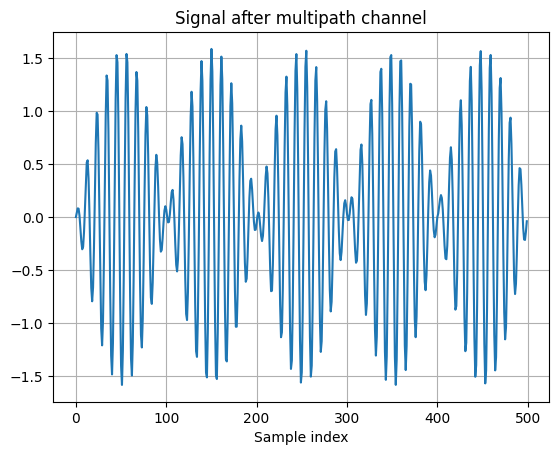

In [9]:
def multipath_channel(s, alpha, delay_samples):
  s_delayed = np.concatenate([np.zeros(delay_samples), s[:-delay_samples]])
  r_clean = np.sqrt(1 - alpha**2) * s + alpha * s_delayed
  return r_clean

r_clean = multipath_channel(s, alpha, Nmu)

plt.plot(r_clean[:5*Ns])
plt.title("Signal after multipath channel")
plt.xlabel("Sample index")
plt.grid()
plt.show()

In [10]:
delay_samples = mu
delay_seconds = delay_samples / fs

P0 = 1 - alpha**2
P1 = alpha**2

delays = np.array([0, delay_seconds])
powers = np.array([P0, P1])

mean_delay = np.sum(powers * delays) / np.sum(powers)
tau_rms = np.sqrt(np.sum(powers * (delays - mean_delay)**2) / np.sum(powers))

Bc_50 = 1 / (5 * tau_rms)
Bc_90 = 1 / (50 * tau_rms)
Bc_simple = 1 / delay_seconds

Rs = fs / N
B_signal = Rs

print(delay_samples)
print(delay_seconds)
print(tau_rms)
print(Bc_simple)
print(Bc_50)
print(Bc_90)
print(B_signal)

if B_signal < Bc_50:
    print("Narrowband assumption is satisfied.")
else:
    print("Narrowband assumption is not clearly satisfied.")

print("Coherence time is very large (static channel)")

NameError: name 'N' is not defined

## AWGN
- Appy gaussian noice to signal

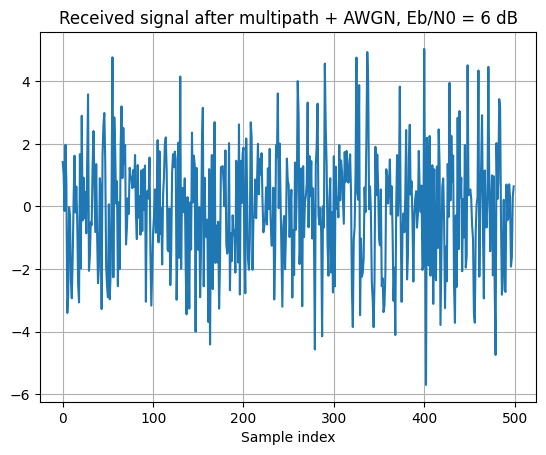

In [ ]:
def add_awgn_passband(r_clean, Eb, EbN0_dB, fs):
  EbN0 = 10**(EbN0_dB / 10)
  N0 = Eb / EbN0
  noise_var = N0 * fs / 2
  noise = np.sqrt(noise_var) * np.random.randn(len(r_clean))
  r = r_clean + noise
  return r

EbN0_dB = 6 # make noise and BER visable
r = add_awgn_passband(r_clean, Eb, EbN0_dB, fs)

plt.plot(r[:5*Ns])
plt.title(f"Received signal after multipath + AWGN, Eb/N0 = {EbN0_dB} dB")
plt.xlabel("Sample index")
plt.grid()
plt.show()

## Downconvert
- Bring back to I/Q baseband from passband baseband

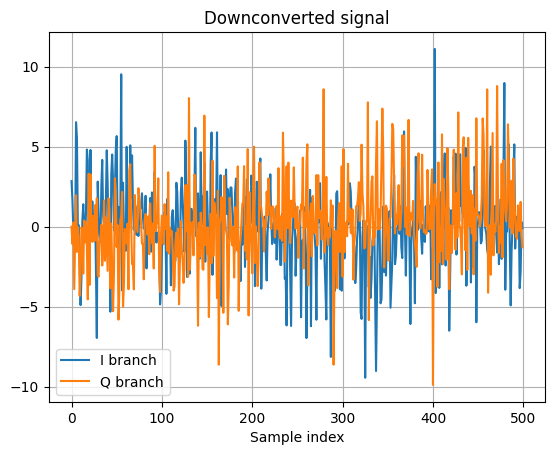

In [ ]:
def downconvert(r, fc, fs):
    n = np.arange(len(r))
    r_i = 2 * r * np.cos(2 * np.pi * fc * n / fs)
    r_q = -2 * r * np.sin(2 * np.pi * fc * n / fs)
    return r_i, r_q

r_i, r_q = downconvert(r, fc, fs)

plt.plot(r_i[:5*Ns], label="I branch")
plt.plot(r_q[:5*Ns], label="Q branch")
plt.title("Downconverted signal")
plt.xlabel("Sample index")
plt.grid()
plt.legend()
plt.show()

## Apply matched filter
- Extract symbol energy for pulse

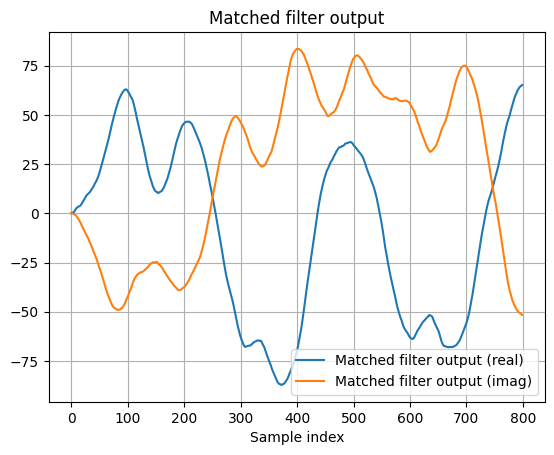

In [ ]:
def matched_filter(x, pulse):
  h = pulse[::-1]
  return np.convolve(x, h, mode='full')

y_i = matched_filter(r_i, p)
y_q = matched_filter(r_q, p)
y = y_i + 1j * y_q

plt.plot(np.real(y[:8*Ns]), label="Matched filter output (real)")
plt.plot(np.imag(y[:8*Ns]), label="Matched filter output (imag)")
plt.title("Matched filter output")
plt.xlabel("Sample index")
plt.grid()
plt.legend()
plt.show()

## Sample once per symbol
- Turns symbol waveform to complex number

Number of received symbol samples = 5000


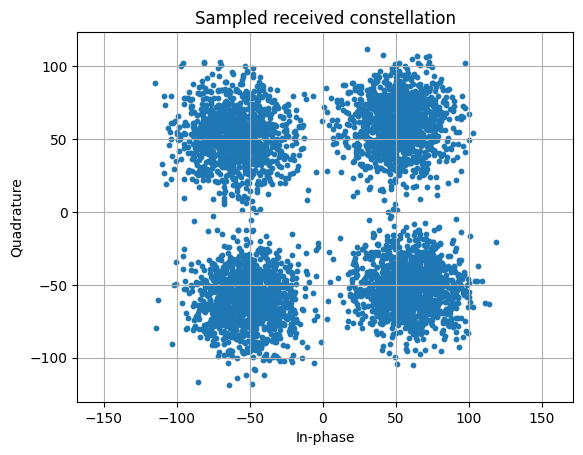

In [ ]:
offset = Ns - 1
z = y[offset : offset + len(symbols)*Ns : Ns]

print("Number of received symbol samples =", len(z))

plt.scatter(z.real, z.imag, s=10)
plt.title("Sampled received constellation")
plt.xlabel("In-phase")
plt.ylabel("Quadrature")
plt.axis("equal")
plt.grid()
plt.show()

## COnvert symbols to bits

In [ ]:
def qpsk_to_bits(z):
    bits_hat = []

    for sym in z:
        re = np.real(sym)
        im = np.imag(sym)

        if re >= 0 and im >= 0:
            bits_hat.extend([0, 0])
        elif re < 0 and im >= 0:
            bits_hat.extend([1, 0])
        elif re < 0 and im < 0:
            bits_hat.extend([1, 1])
        else:
            bits_hat.extend([0, 1])

    return np.array(bits_hat)

bits_hat = qpsk_to_bits(z)
bits_hat = bits_hat[:len(bits)]

## Compute BER

In [ ]:
BER = np.mean(bits != bits_hat)
print("BER =", BER)

BER = 0.0014


## Simulate

In [ ]:
def simulate_ber(EbN0_dB, Nbits, alpha, fs, fc, Ts, mu):
    Ns = int(round(fs * Ts))
    Nmu = int(round(mu * fs))

    # pulse
    t_pulse = np.arange(Ns) / fs
    p = np.sin(np.pi * t_pulse / Ts)

    # bits and symbols
    bits = np.random.randint(0, 2, Nbits)
    symbols = bits_to_qpsk(bits)

    # TX
    x_bb = pulse_shape(symbols, p)
    s = upconvert(x_bb, fc, fs)

    # energy
    E_total = signal_energy(s, fs)
    Eb = E_total / len(bits)

    # channel
    r_clean = multipath_channel(s, alpha, Nmu)
    r = add_awgn_passband(r_clean, Eb, EbN0_dB, fs)

    # RX
    r_i, r_q = downconvert(r, fc, fs)
    y_i = matched_filter(r_i, p)
    y_q = matched_filter(r_q, p)
    y = y_i + 1j * y_q

    offset = Ns - 1
    z = y[offset : offset + len(symbols)*Ns : Ns]

    bits_hat = qpsk_to_bits(z)
    bits_hat = bits_hat[:len(bits)]

    num_errors = np.sum(bits != bits_hat)
    return num_errors, len(bits)

## Estimate BER

In [ ]:
def estimate_ber_point(
    EbN0_dB, 
    alpha, 
    fs, 
    fc, 
    Ts, 
    mu,
    min_errors=100, 
    max_bits=2_000_000, 
    block_bits=100_000
):
    total_errors = 0
    total_bits = 0

    while total_errors < min_errors and total_bits < max_bits:
        errors, nbits = simulate_ber(
            EbN0_dB=EbN0_dB,
            Nbits=block_bits,
            alpha=alpha,
            fs=fs,
            fc=fc,
            Ts=Ts,
            mu=mu
        )
        total_errors += errors
        total_bits += nbits

    ber = total_errors / total_bits
    return ber, total_errors, total_bits

In [ ]:
np.random.seed(0)
EbN0_dB_values = np.arange(0, 12, 1)

ber_values_awgn = []
error_counts_awgn = []
bit_counts_awgn = []

ber_values = []
error_counts = []
bit_counts = []

print("AWGN sanity check (alpha = 0)")
print("Eb/N0 [dB] | BER        | errors | bits")
for ebn0 in EbN0_dB_values:
    ber, nerr, nbits = estimate_ber_point(
        EbN0_dB=ebn0,
        alpha=0.0,
        fs=fs,
        fc=fc,
        Ts=Ts,
        mu=mu
    )
    ber_values_awgn.append(ber)
    error_counts_awgn.append(nerr)
    bit_counts_awgn.append(nbits)
    print(f"{ebn0:10d} | {ber:10.3e} | {nerr:6d} | {nbits:7d}")

for ebn0 in EbN0_dB_values:
    ber, nerr, nbits = estimate_ber_point(
        EbN0_dB=ebn0,
        alpha=alpha,
        fs=fs,
        fc=fc,
        Ts=Ts,
        mu=mu
    )
    ber_values.append(ber)
    error_counts.append(nerr)
    bit_counts.append(nbits)
    print(f"{ebn0:10d} | {ber:10.3e} | {nerr:6d} | {nbits:7d}")
    
print("\nSpecified channel (alpha = 1/6)")
print("Eb/N0 [dB] | BER        | errors | bits")
    
ber_values_awgn = np.array(ber_values_awgn)
ber_values = np.array(ber_values)

AWGN sanity check (alpha = 0)
Eb/N0 [dB] | BER        | errors | bits
         0 |  7.859e-02 |   7859 |  100000
         1 |  5.519e-02 |   5519 |  100000
         2 |  3.723e-02 |   3723 |  100000
         3 |  2.223e-02 |   2223 |  100000
         4 |  1.293e-02 |   1293 |  100000
         5 |  5.640e-03 |    564 |  100000
         6 |  2.870e-03 |    287 |  100000
         7 |  7.200e-04 |    144 |  200000
         8 |  1.667e-04 |    100 |  600000
         9 |  2.900e-05 |     58 | 2000000
        10 |  6.000e-06 |     12 | 2000000
        11 |  5.000e-07 |      1 | 2000000
         0 |  5.785e-02 |   5785 |  100000
         1 |  3.914e-02 |   3914 |  100000
         2 |  2.444e-02 |   2444 |  100000
         3 |  1.363e-02 |   1363 |  100000
         4 |  6.960e-03 |    696 |  100000
         5 |  3.110e-03 |    311 |  100000
         6 |  1.030e-03 |    103 |  100000
         7 |  2.800e-04 |    112 |  400000
         8 |  6.176e-05 |    105 | 1700000
         9 |  1.050e-05 |  

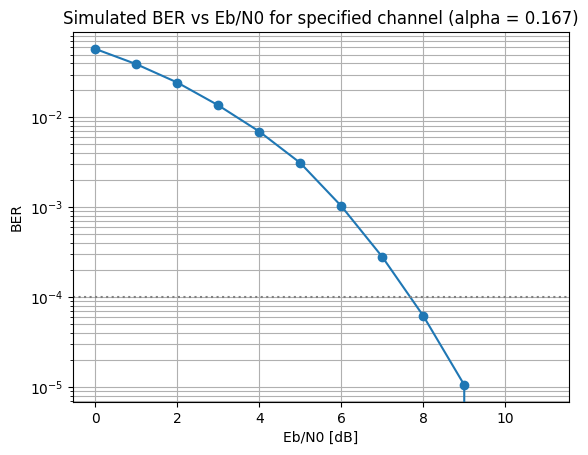

In [ ]:
plt.semilogy(EbN0_dB_values, ber_values, 'o-')
plt.axhline(1e-4, color='gray', linestyle=':')
plt.title(f"Simulated BER vs Eb/N0 for specified channel (alpha = {alpha:.3f})")
plt.xlabel("Eb/N0 [dB]")
plt.ylabel("BER")
plt.grid(True, which='both')
plt.show()

## COmpare to theorethical

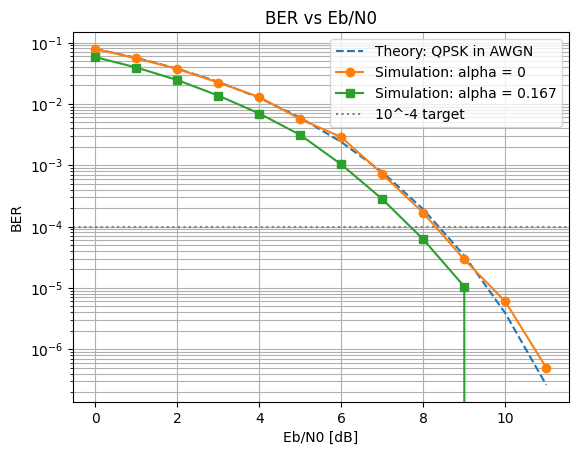

In [ ]:
EbN0_lin = 10**(EbN0_dB_values / 10)
ber_theory = 0.5 * erfc(np.sqrt(EbN0_lin))

plt.semilogy(EbN0_dB_values, ber_theory, '--', label='Theory: QPSK in AWGN')
plt.semilogy(EbN0_dB_values, ber_values_awgn, 'o-', label='Simulation: alpha = 0')
plt.semilogy(EbN0_dB_values, ber_values, 's-', label=f'Simulation: alpha = {alpha:.3f}')
plt.axhline(1e-4, color='gray', linestyle=':', label='10^-4 target')
plt.title("BER vs Eb/N0")
plt.xlabel("Eb/N0 [dB]")
plt.ylabel("BER")
plt.grid(True, which='both')
plt.legend()
plt.show()